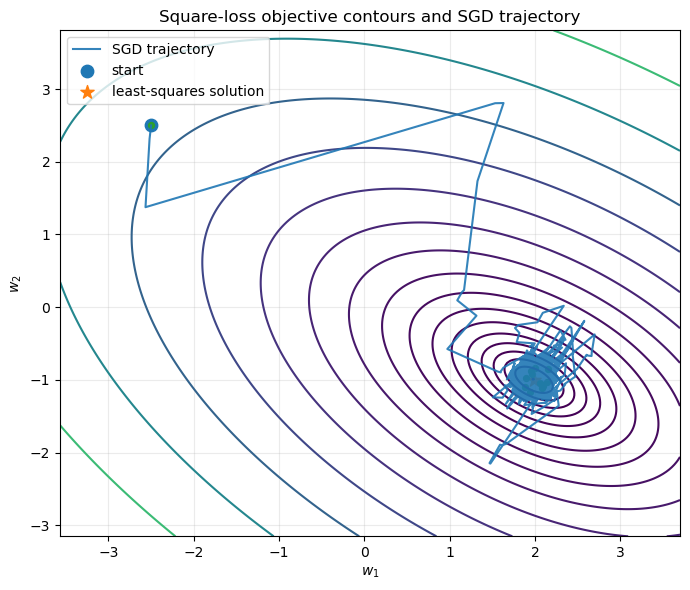

Estimated solution from least squares: [ 1.98748335 -0.99832738]
Final SGD iterate: [ 2.1339451  -1.02778937]
Initial objective: 9.59780290337999
Final objective: 0.04737434223232393


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(0)

# ------------------------------------------------------------
# Generate simple 2D Gaussian data for linear regression
# y = x^T w_true + noise
# ------------------------------------------------------------
n = 300
d = 2

mean = np.array([0.0, 0.0])
cov = np.array([[1.0, 0.6],
                [0.6, 1.5]])
X = rng.multivariate_normal(mean, cov, size=n)

w_true = np.array([2.0, -1.0])
noise = 0.3 * rng.standard_normal(n)
y = X @ w_true + noise

# ------------------------------------------------------------
# Square-loss objective:
#   f(w) = (1/2n) sum_i (x_i^T w - y_i)^2
# SGD update on one sample i:
#   w <- w - lr * (x_i^T w - y_i) x_i
# ------------------------------------------------------------
def objective(w):
    r = X @ w - y
    return 0.5 * np.mean(r**2)

def sgd(X, y, w0, lr=0.08, epochs=12, seed=1):
    rng_local = np.random.default_rng(seed)
    w = w0.copy()
    traj = [w.copy()]
    losses = [objective(w)]

    n = len(y)
    for _ in range(epochs):
        order = rng_local.permutation(n)
        for i in order:
            xi = X[i]
            yi = y[i]
            grad_i = (xi @ w - yi) * xi
            w = w - lr * grad_i
            traj.append(w.copy())
            losses.append(objective(w))
    return np.array(traj), np.array(losses)

w0 = np.array([-2.5, 2.5])
traj, losses = sgd(X, y, w0, lr=0.2, epochs=10, seed=1)

# Closed-form least-squares solution for reference
w_star, *_ = np.linalg.lstsq(X, y, rcond=None)

# ------------------------------------------------------------
# Build contour plot of the full objective in parameter space
# ------------------------------------------------------------
pad = 1.0
w1_min = min(traj[:, 0].min(), w_star[0]) - pad
w1_max = max(traj[:, 0].max(), w_star[0]) + pad
w2_min = min(traj[:, 1].min(), w_star[1]) - pad
w2_max = max(traj[:, 1].max(), w_star[1]) + pad

g1 = np.linspace(w1_min, w1_max, 220)
g2 = np.linspace(w2_min, w2_max, 220)
W1, W2 = np.meshgrid(g1, g2)
Z = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Z[i, j] = objective(np.array([W1[i, j], W2[i, j]]))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

levels = np.geomspace(Z.min() + 1e-4, Z.max(), 18)
ax.contour(W1, W2, Z, levels=levels)

ax.plot(traj[:, 0], traj[:, 1], linewidth=1.5, alpha=0.9, label="SGD trajectory")
ax.scatter(traj[0, 0], traj[0, 1], s=80, marker="o", label="start")
ax.scatter(w_star[0], w_star[1], s=100, marker="*", label="least-squares solution")

# Mark a few intermediate points to make the path easier to see
idx = np.linspace(0, len(traj) - 1, 12, dtype=int)
ax.scatter(traj[idx, 0], traj[idx, 1], s=18)

ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.set_title("Square-loss objective contours and SGD trajectory")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print("Estimated solution from least squares:", w_star)
print("Final SGD iterate:", traj[-1])
print("Initial objective:", losses[0])
print("Final objective:", losses[-1])